Um laboratório de análises clínicas, com base em dados de pacientes que realizaram exames de diabetes, gostaria de prever, com base em características como idade, peso e altura, qual o resultado esperado do exame para novos pacientes.<br><br>Para isso, iremos treinar um algoritmo supervisionado (dado que temos dados reais dos resultados) para criar um modelo preditivo que atenda à necessidade deste laboratório.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df_exame = pd.read_csv('exame_diabetes.csv')
df_exame.drop(columns=["id_paciente"], inplace=True) #remove coluna nao importante
df_exame.head()

,genero,idade,peso,altura,resultado
0,M,46,83,165,98
1,F,23,83,164,82
2,M,39,71,154,93
3,F,26,103,165,95
4,M,27,55,176,100


In [13]:
#Converter variavel categorica para numerica com One-hot-encodding
df_exame = pd.get_dummies(df_exame, columns=["genero"], dtype="int64")
df_exame.head()

,idade,peso,altura,resultado,genero_F,genero_M
0,46,83,165,98,0,1
1,23,83,164,82,1,0
2,39,71,154,93,0,1
3,26,103,165,95,1,0
4,27,55,176,100,0,1


<Axes: >

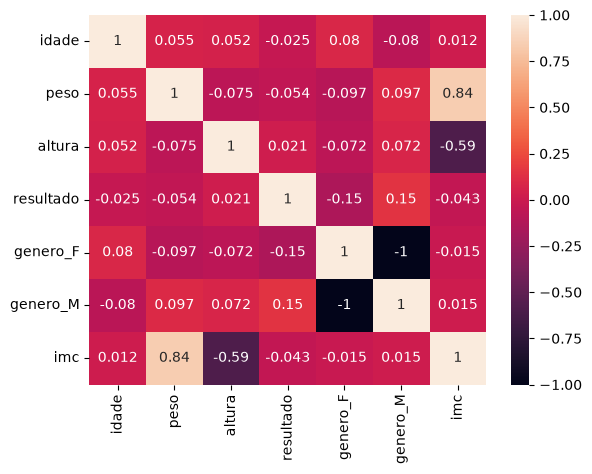

In [37]:
#mapa de calor entre variaveis
sns.heatmap(df_exame.corr(),vmin=-1,vmax=1,annot=True) #informando escala

<Axes: >

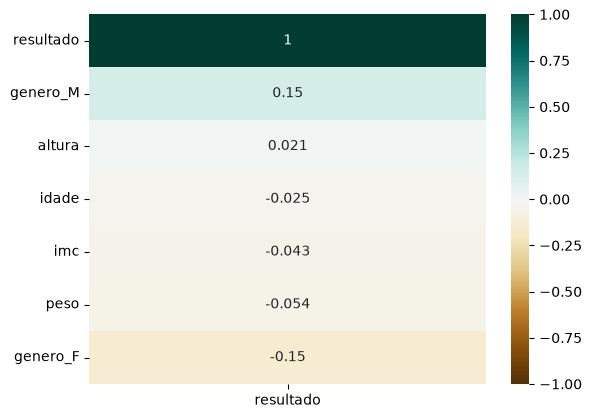

In [36]:
#mapa de calor só com target resultado

sns.heatmap(df_exame.corr()[['resultado']].sort_values(by='resultado',ascending=False),vmin=-1,vmax=1,annot=True,cmap='BrBG')#filtrei só por resultado

array([[<Axes: title={'center': 'idade'}>,
        <Axes: title={'center': 'peso'}>,
        <Axes: title={'center': 'altura'}>,
        <Axes: title={'center': 'resultado'}>],
       [<Axes: title={'center': 'genero_F'}>,
        <Axes: title={'center': 'genero_M'}>,
        <Axes: title={'center': 'imc'}>, <Axes: >]], dtype=object)

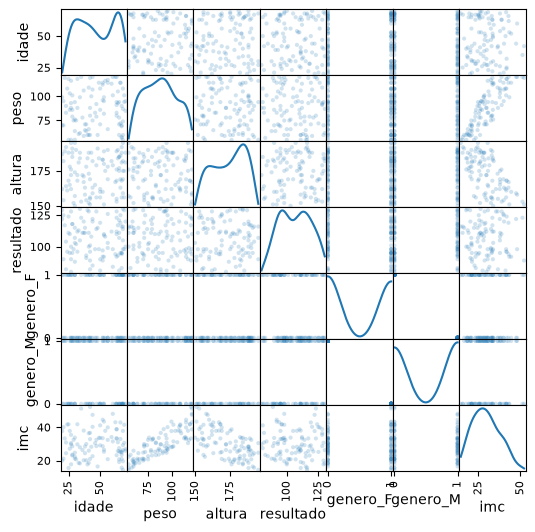

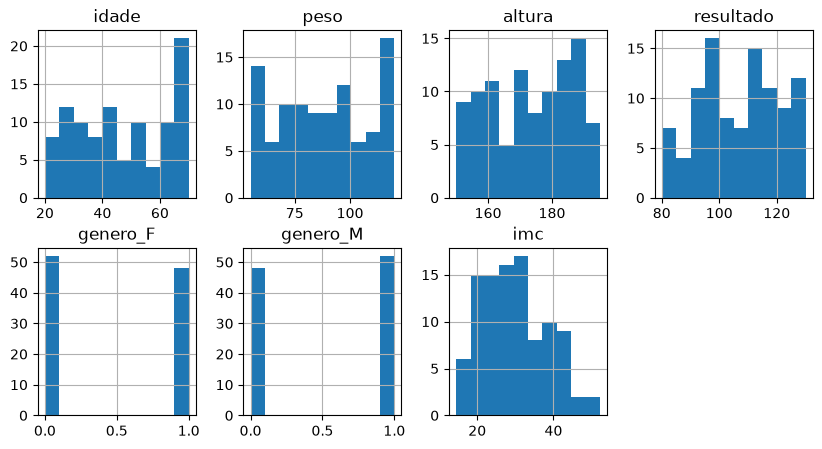

In [41]:
#plot de dispersao com distribuicao

pd.plotting.scatter_matrix(df_exame,alpha=0.2,figsize=(6,6),diagonal='kde')
df_exame.hist(layout=(2,4),figsize=(10,5))

In [34]:
#feature nova, imc
df_exame['imc'] = df_exame['peso']/((df_exame['altura']/100)**2)

<Axes: xlabel='tempo_casa', ylabel='salario'>

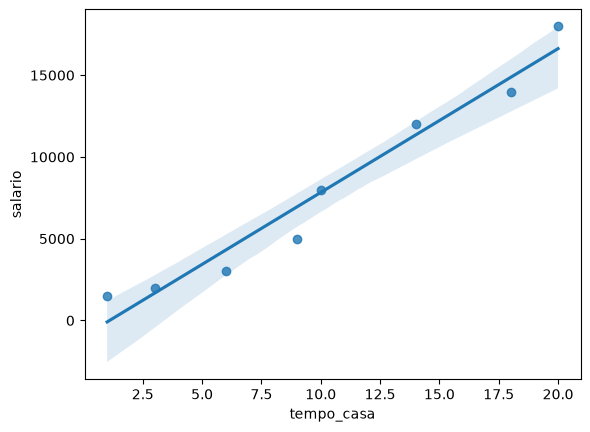

In [ ]:
#dict_regressao = {
#    'tempo_casa': [1,3,6,9,10,14,18,20],
#    'salario': [1500,2000,3000,5000,8000,12000,14000,18000]
#}

#df_regressao = pd.DataFrame.from_dict(dict_regressao)
#sns.regplot(data=df_regressao,x='tempo_casa',y='salario')

In [54]:
#sklearn import 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
x = df_exame.drop(columns=['imc','resultado']) #variaveis independentes 
y = df_exame['resultado'] #dependentes

In [ ]:
x_train, x_test,y_train,y_test = train_test_split(x,y,train_size=0.7,random_state=51)

In [61]:
#treinar algortimo regressao modelo 1
model1 = LinearRegression().fit(x_train,y_train)
y_pred = model1.predict(x_test)
y_pred

array([ 99.6684178 , 111.15467732, 113.11211654, 108.92788908,
       106.38206401, 107.30939688, 109.65461594, 112.00335574,
       111.06900447, 109.78672617, 112.35808062, 112.28232464,
       111.9380202 , 108.10634945,  98.35810505, 108.24066307,
       107.47444699, 107.86866238, 108.45528721, 106.47405474,
       108.68462818, 107.39800684, 105.52920918, 101.5310878 ,
       107.73027652, 103.02436766, 105.65307386, 112.03833836,
       105.49217347, 100.44933075])

In [64]:
#r2 score

model1.score(x_train,y_train)
model1.score(x_test,y_test)

r2_score(y_test,y_pred)

-0.1364090447910642

In [65]:
#MEA (erro medio absoluto)
mean_absolute_error(y_test,y_pred)

12.695569181179541

In [68]:
#segundo modelo
x = pd.DataFrame(df_exame['imc'])
y = df_exame['resultado']

x_train, x_test,y_train,y_test = train_test_split(x,y,train_size=0.7,random_state=51)

model2 = LinearRegression().fit(x_train,y_train)
y_pred = model2.predict(x_test)
model2.score(x_test,y_test)
mean_absolute_error(y_test,y_pred)

12.5056514070601

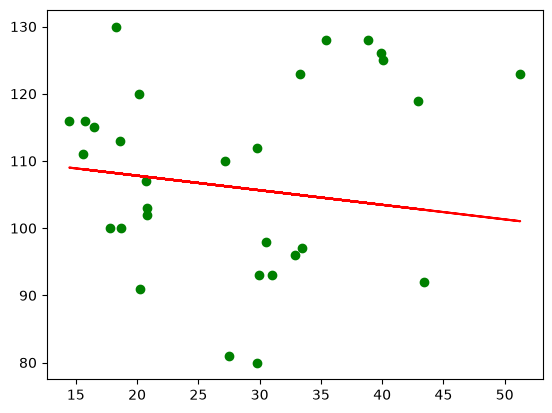

In [73]:
plt.scatter(x_test,y_test,color='g')
plt.plot(x_test,y_pred,color='r')